In [34]:
from pathlib import Path
import numpy as np
import wfdb # type: ignore
import matplotlib.pyplot as plt
import pandas as pd
import csv
import pywt # type: ignore
from scipy.signal import hilbert
from scipy.signal import find_peaks
import ast

In [35]:
df_pacientes=pd.read_csv("C:\\Users\\Ana\\Documents\\4º GITT+BA (2025-2026)\\TFG\\TFG\\ptbxl_database.csv")
df_scp=pd.read_csv("C:\\Users\\Ana\\Documents\\4º GITT+BA (2025-2026)\\TFG\\TFG\\scp_statements.csv",sep=";")

In [36]:
df_pacientes = df_pacientes[(df_pacientes["age"] != df_pacientes["age"].max()) & (df_pacientes["age"] >= 18)]

In [37]:
PRIMARY_DARK = "#0B2E26"
PRIMARY = "#145A4A"
PRIMARY_LIGHT = "#3F8F7A"

NEUTRAL_DARK = "#2B2B2B"
NEUTRAL_LIGHT = "#D9D9D9"

In [38]:
import numpy as np

df_pacientes['sex_clean'] = df_pacientes['sex'].replace({
    0: 'Mujer',
    1: 'Hombre',
    'F': 'Mujer',
    'M': 'Hombre',
    'female': 'Mujer',
    'male': 'Hombre'
})

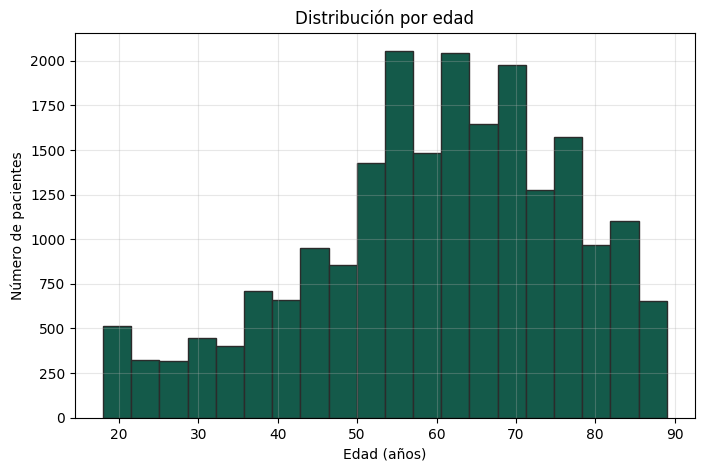

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df_pacientes['age'].dropna(), bins=20,edgecolor=NEUTRAL_DARK,  color=PRIMARY)

plt.title("Distribución por edad")
plt.xlabel("Edad (años)")
plt.ylabel("Número de pacientes")

plt.grid(alpha=0.3)
plt.show()

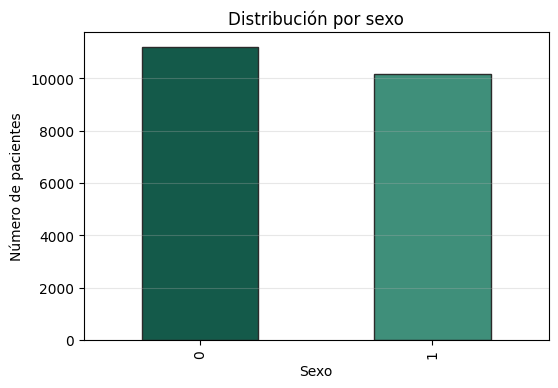

In [40]:
import matplotlib.pyplot as plt

sex_counts = df_pacientes['sex'].value_counts()

plt.figure(figsize=(6,4))
sex_counts.plot(kind='bar', edgecolor=NEUTRAL_DARK,color=[PRIMARY,PRIMARY_LIGHT])

plt.title("Distribución por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de pacientes")
plt.grid(axis='y', alpha=0.3)

plt.show()

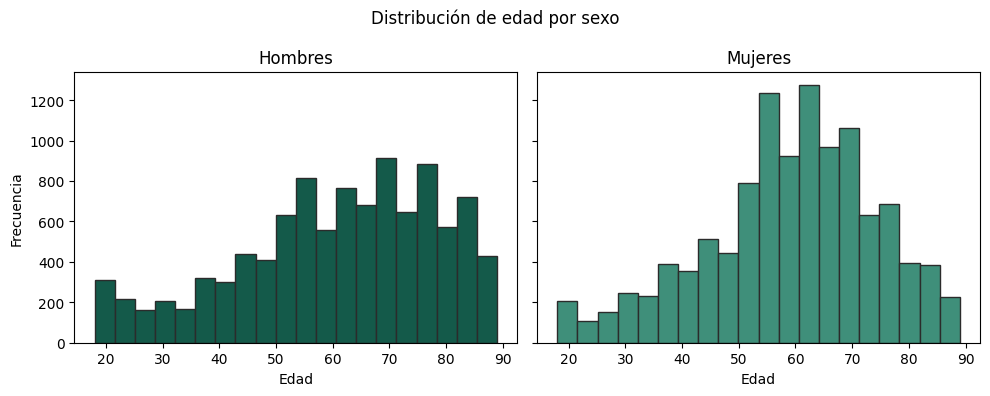

In [41]:
import matplotlib.pyplot as plt

hombres = df_pacientes[df_pacientes['sex_clean'] == 'Hombre']['age'].dropna()
mujeres = df_pacientes[df_pacientes['sex_clean'] == 'Mujer']['age'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

axes[0].hist(hombres, bins=20, color=PRIMARY, edgecolor=NEUTRAL_DARK)
axes[0].set_title("Hombres")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(mujeres, bins=20, color=PRIMARY_LIGHT, edgecolor=NEUTRAL_DARK)
axes[1].set_title("Mujeres")
axes[1].set_xlabel("Edad")

plt.suptitle("Distribución de edad por sexo")
plt.tight_layout()
plt.show()

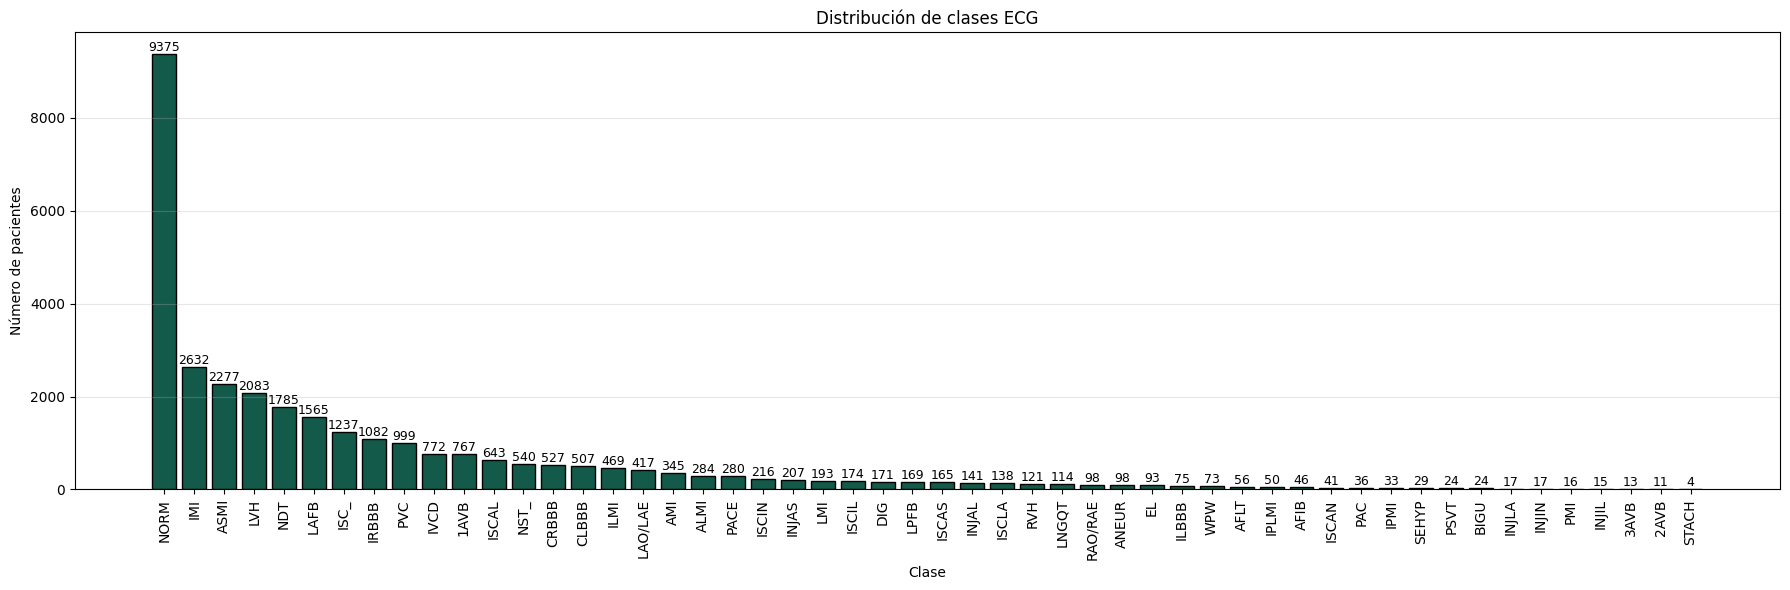

In [42]:
import ast
from collections import Counter
import matplotlib.pyplot as plt

# contador de enfermedades
conteo_enfermedades = Counter()

# recorrer todos los pacientes
for etiqueta in df_pacientes['scp_codes']:

    d = ast.literal_eval(etiqueta)

    for enfermedad, probabilidad in d.items():

        # contar solo si aparece
        if probabilidad > 0:
            conteo_enfermedades[enfermedad] += 1

# ordenar de mayor a menor
conteo_enfermedades = dict(
    sorted(
        conteo_enfermedades.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

# gráfico
plt.figure(figsize=(18,6))

bars=plt.bar(
    conteo_enfermedades.keys(),
    conteo_enfermedades.values(),
    color="#145A4A",
    edgecolor="black"
)

plt.title("Distribución de clases ECG")
plt.xlabel("Clase")
plt.ylabel("Número de pacientes")

plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

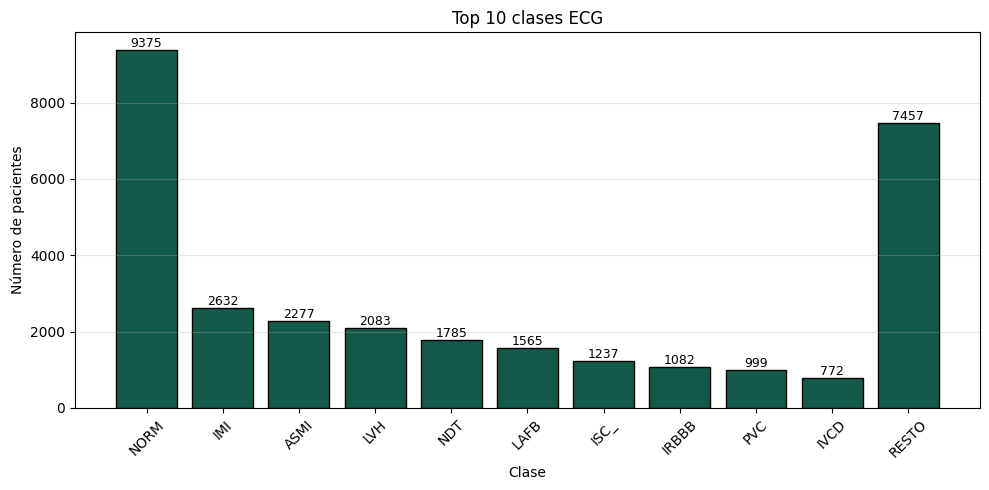

In [43]:
plt.figure(figsize=(10,5))
conteo_ordenado = dict(
    sorted(
        conteo_enfermedades.items(),
        key=lambda x: x[1],
        reverse=True
    )
)
top_10 = dict(list(conteo_ordenado.items())[:10])

resto = sum(list(conteo_ordenado.values())[10:])

top_10['RESTO'] = resto

bars = plt.bar(
    top_10.keys(),
    top_10.values(),
    color="#145A4A",
    edgecolor="black"
)

plt.title("Top 10 clases ECG")
plt.xlabel("Clase")
plt.ylabel("Número de pacientes")

plt.xticks(rotation=45)

# 👇 valores encima
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
ENFERMEDADES=list(df_scp['diagnostic_class'].unique())
ENFERMEDADES=ENFERMEDADES[:-1]
enfermedad_grupo=dict(zip(df_scp.iloc[:, 0], df_scp['diagnostic_class'])) 


In [45]:
enfermedad_grupo


{'NDT': 'STTC',
 'NST_': 'STTC',
 'DIG': 'STTC',
 'LNGQT': 'STTC',
 'NORM': 'NORM',
 'IMI': 'MI',
 'ASMI': 'MI',
 'LVH': 'HYP',
 'LAFB': 'CD',
 'ISC_': 'STTC',
 'IRBBB': 'CD',
 '1AVB': 'CD',
 'IVCD': 'CD',
 'ISCAL': 'STTC',
 'CRBBB': 'CD',
 'CLBBB': 'CD',
 'ILMI': 'MI',
 'LAO/LAE': 'HYP',
 'AMI': 'MI',
 'ALMI': 'MI',
 'ISCIN': 'STTC',
 'INJAS': 'MI',
 'LMI': 'MI',
 'ISCIL': 'STTC',
 'LPFB': 'CD',
 'ISCAS': 'STTC',
 'INJAL': 'MI',
 'ISCLA': 'STTC',
 'RVH': 'HYP',
 'ANEUR': 'STTC',
 'RAO/RAE': 'HYP',
 'EL': 'STTC',
 'WPW': 'CD',
 'ILBBB': 'CD',
 'IPLMI': 'MI',
 'ISCAN': 'STTC',
 'IPMI': 'MI',
 'SEHYP': 'HYP',
 'INJIN': 'MI',
 'INJLA': 'MI',
 'PMI': 'MI',
 '3AVB': 'CD',
 'INJIL': 'MI',
 '2AVB': 'CD',
 'ABQRS': nan,
 'PVC': nan,
 'STD_': nan,
 'VCLVH': nan,
 'QWAVE': nan,
 'LOWT': nan,
 'NT_': nan,
 'PAC': nan,
 'LPR': nan,
 'INVT': nan,
 'LVOLT': nan,
 'HVOLT': nan,
 'TAB_': nan,
 'STE_': nan,
 'PRC(S)': nan,
 'SR': nan,
 'AFIB': nan,
 'STACH': nan,
 'SARRH': nan,
 'SBRAD': nan,
 'PACE': 

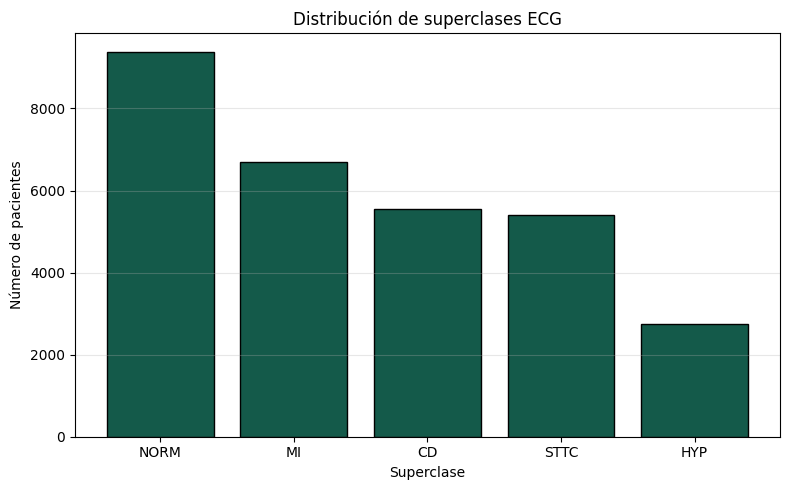

In [46]:
conteo_superclases = Counter()
import math

for etiqueta in df_pacientes['scp_codes']:

    d = ast.literal_eval(etiqueta)

    for enfermedad, probabilidad in d.items():

        if probabilidad > 0:

            if enfermedad in enfermedad_grupo:

                superclase = enfermedad_grupo[enfermedad]
                # evitar NaN o None
                if isinstance(superclase, str):
                    conteo_superclases[superclase] += 1

conteo_superclases = dict(
    sorted(conteo_superclases.items(),
           
           key=lambda x: x[1],
           reverse=True)
)

plt.figure(figsize=(8,5))

plt.bar(
    conteo_superclases.keys(),
    conteo_superclases.values(),
    color="#145A4A",
    edgecolor="black"
)

plt.title("Distribución de superclases ECG")
plt.xlabel("Superclase")
plt.ylabel("Número de pacientes")

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
#Matriz de Co-ocurrencia de enfermedades
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [48]:
all_labels = set()

for etiqueta in df_pacientes['scp_codes']:
    d = ast.literal_eval(etiqueta)
    for k, v in d.items():
        if v > 0:
            all_labels.add(k)

all_labels = sorted(list(all_labels))

In [49]:
label_to_idx = {label: i for i, label in enumerate(all_labels)}

co_matrix = np.zeros((len(all_labels), len(all_labels)))

In [50]:
for etiqueta in df_pacientes['scp_codes']:

    d = ast.literal_eval(etiqueta)

    present_labels = [k for k, v in d.items() if v > 0]

    for i in range(len(present_labels)):
        for j in range(i + 1, len(present_labels)):

            l1 = present_labels[i]
            l2 = present_labels[j]

            idx1 = label_to_idx[l1]
            idx2 = label_to_idx[l2]

            co_matrix[idx1][idx2] += 1
            co_matrix[idx2][idx1] += 1

In [51]:
co_df = pd.DataFrame(
    co_matrix,
    index=all_labels,
    columns=all_labels
)

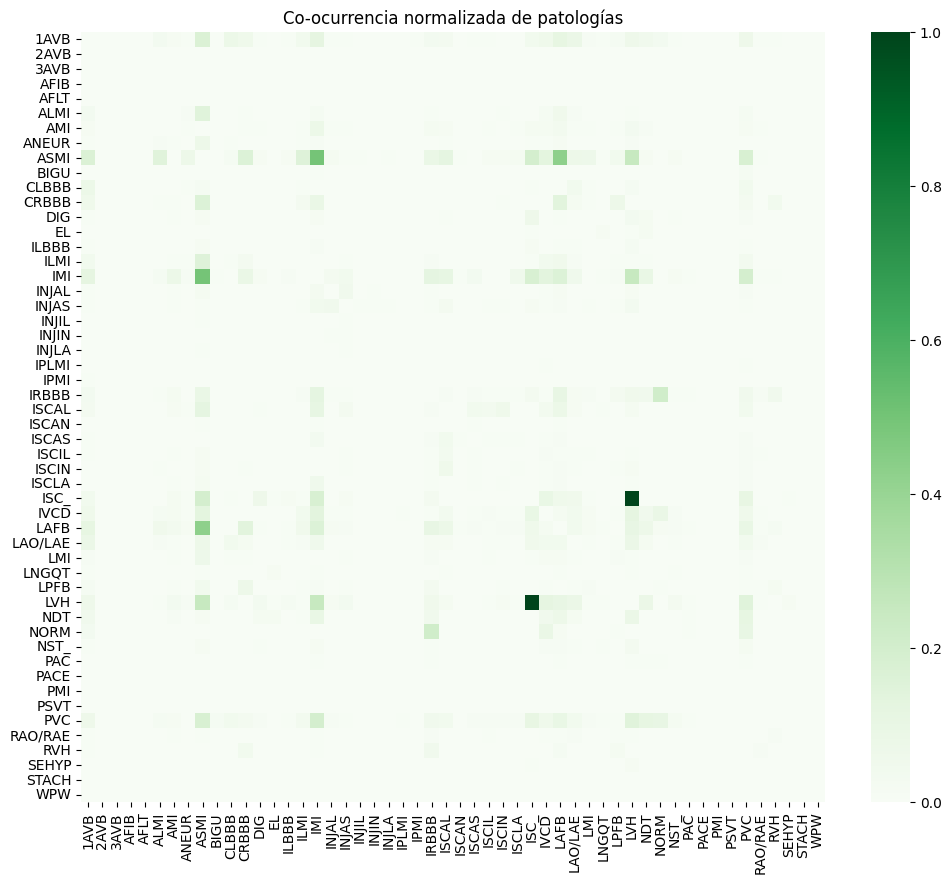

In [53]:
import seaborn as sns
import numpy as np

co_df_norm = co_df / co_df.values.max()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    co_df_norm,
    cmap="Greens",
    vmin=0,
    vmax=1
)

plt.title("Co-ocurrencia normalizada de patologías")
plt.show()

In [54]:
from collections import Counter
import ast

conteo = Counter()

for etiqueta in df_pacientes['scp_codes']:

    d = ast.literal_eval(etiqueta)

    for k, v in d.items():
        if v > 0:
            conteo[k] += 1

# TOP 20
top_n = 20

top_classes = [
    c for c, _ in conteo.most_common(top_n)
]

In [55]:
import pandas as pd

co_df_top = co_df.loc[top_classes, top_classes]

In [56]:
import numpy as np

co_df_top_log = np.log1p(co_df_top)

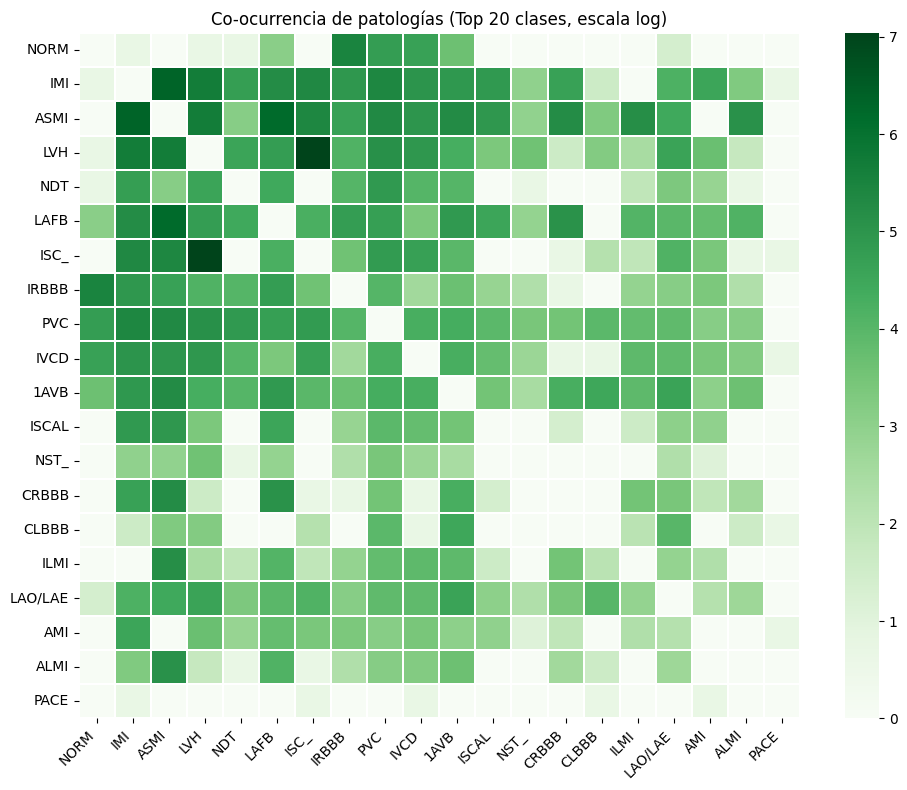

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    co_df_top_log,
    cmap="Greens",
    linewidths=0.3
)

plt.title("Co-ocurrencia de patologías (Top 20 clases, escala log)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [58]:
import ast
from collections import Counter

pair_counts = Counter()

for etiqueta in df_pacientes['scp_codes']:

    d = ast.literal_eval(etiqueta)

    present = [k for k, v in d.items() if v > 0]

    for i in range(len(present)):
        for j in range(i+1, len(present)):

            pair = tuple(sorted([present[i], present[j]]))
            pair_counts[pair] += 1

In [59]:
cooccurrence_list = [
    (a, b, count)
    for (a, b), count in pair_counts.items()
]

# ordenar
cooccurrence_list = sorted(cooccurrence_list, key=lambda x: x[2], reverse=True)

In [60]:
for a, b, c in cooccurrence_list[:20]:
    print(f"{a} ↔ {b}: {c}")

ISC_ ↔ LVH: 1139
ASMI ↔ IMI: 567
ASMI ↔ LAFB: 486
ASMI ↔ LVH: 289
IMI ↔ LVH: 288
IRBBB ↔ NORM: 241
ASMI ↔ ISC_: 224
IMI ↔ PVC: 223
IMI ↔ ISC_: 208
ASMI ↔ PVC: 206
1AVB ↔ ASMI: 195
IMI ↔ LAFB: 186
ASMI ↔ CRBBB: 186
ASMI ↔ ILMI: 175
LVH ↔ PVC: 166
ALMI ↔ ASMI: 165
CRBBB ↔ LAFB: 157
IMI ↔ IVCD: 152
ASMI ↔ IVCD: 148
IMI ↔ IRBBB: 139


In [61]:
co_matrix_dict = {}

for (a, b), c in pair_counts.items():
    co_matrix_dict.setdefault(a, {})[b] = c
    co_matrix_dict.setdefault(b, {})[a] = c

In [63]:
print(co_matrix_dict)

{'DIG': {'NST_': 13, 'IMI': 20, 'LNGQT': 2, 'LVH': 38, 'ISC_': 74, 'NDT': 31, '1AVB': 12, 'ISCAL': 10, 'ASMI': 18, 'LAFB': 7, 'IRBBB': 4, 'PVC': 15, 'AMI': 7, 'IPLMI': 2, 'LAO/LAE': 4, 'IPMI': 1, 'RAO/RAE': 2, 'ISCIL': 3, 'CLBBB': 2, 'INJAS': 4, 'ISCAS': 2, 'IVCD': 4, 'ILMI': 2, 'INJAL': 1, 'EL': 1, 'CRBBB': 3, 'LPFB': 3, 'PSVT': 1, 'ISCIN': 2, 'ISCAN': 1}, 'NST_': {'DIG': 13, 'IMI': 19, 'LNGQT': 7, 'PVC': 30, '1AVB': 11, 'ASMI': 18, 'EL': 4, 'LVH': 35, 'RAO/RAE': 3, 'IVCD': 15, 'LAFB': 17, 'AMI': 2, 'LAO/LAE': 9, 'IRBBB': 9, 'AFIB': 1, 'LMI': 3, 'LPFB': 4, 'NDT': 1, 'IPMI': 1, 'PAC': 2}, 'IMI': {'LNGQT': 13, 'NST_': 19, 'DIG': 20, 'LAFB': 186, 'ISCLA': 63, 'SEHYP': 1, 'ASMI': 567, 'ALMI': 26, 'ANEUR': 17, '1AVB': 134, 'NDT': 115, 'PVC': 223, 'CRBBB': 106, 'LVH': 288, 'ISC_': 208, 'ILBBB': 17, 'IRBBB': 139, 'INJAS': 45, 'AMI': 93, 'IVCD': 152, 'CLBBB': 4, 'ISCAN': 7, 'ISCAL': 129, 'LPFB': 16, 'INJAL': 33, 'LAO/LAE': 66, 'PMI': 3, 'EL': 2, 'ISCAS': 36, 'PAC': 5, 'ISCIN': 4, '3AVB': 4, '

In [78]:
import ast
import matplotlib.pyplot as plt

num_labels = []

for etiqueta in df_pacientes['scp_codes']:

   import ast

num_labels = []

for etiqueta in df_pacientes['scp_codes']:

    d = ast.literal_eval(etiqueta)

    # Contar patologías distintas de NORM
    count = sum(
        1
        for enfermedad, probabilidad in d.items()
        if probabilidad > 0 and enfermedad != 'NORM'
    )

    num_labels.append(count)

In [79]:
num_labels.count(0)

8854

In [82]:
from collections import Counter

print(Counter(num_labels))

Counter({0: 8854, 1: 6375, 2: 3824, 3: 1582, 4: 570, 5: 168})


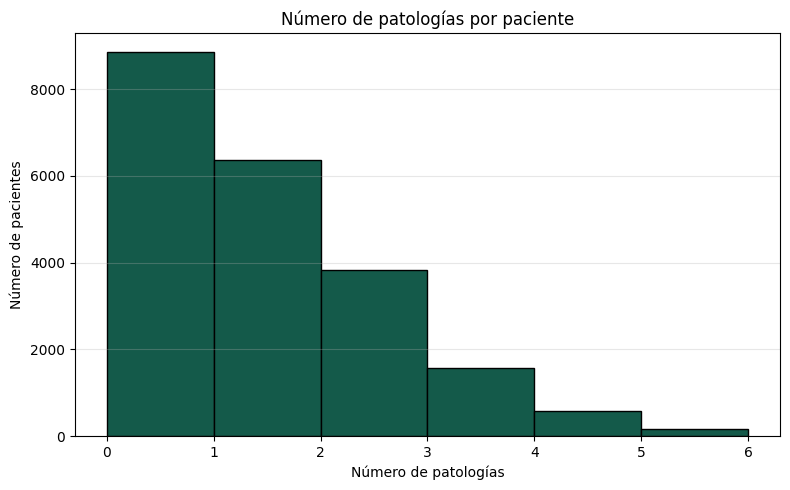

In [83]:
plt.figure(figsize=(8,5))

plt.hist(
    num_labels,
    bins=range(0, max(num_labels)+2),
    color="#145A4A",
    edgecolor="black"
)

plt.title("Número de patologías por paciente")
plt.xlabel("Número de patologías")
plt.ylabel("Número de pacientes")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

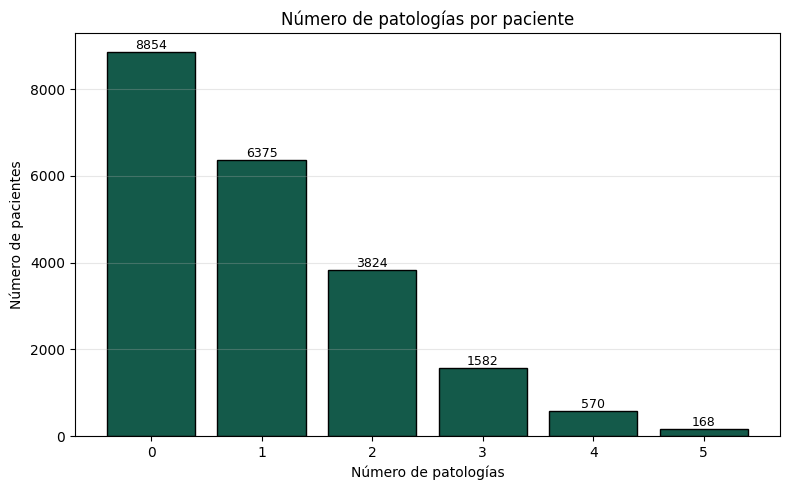

In [85]:
from collections import Counter
import matplotlib.pyplot as plt

conteo = Counter(num_labels)

# ordenar por número de patologías
conteo = dict(sorted(conteo.items()))

plt.figure(figsize=(8,5))

plt.bar(
    conteo.keys(),
    conteo.values(),
    color="#145A4A",
    edgecolor="black"
)

# valor encima de cada barra
for x, y in conteo.items():
    plt.text(
        x,
        y,
        str(y),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Número de patologías por paciente")
plt.xlabel("Número de patologías")
plt.ylabel("Número de pacientes")

plt.xticks(list(conteo.keys()))

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()